# Contact Verification

In this notebook, we will compare the heterogeneous co-simulation of the Controlled Pendulum using `FMUComponent`s and the `MasterPendulum` against a monolithic Modelica reference solution.

We have configured the FEM pendulum and contact as highly stiff in order to a achieve an almost perfectly rigid contact.
This allows us to verify the co-simulation with a multi model component approach against a monolithic Modelica solution.

In [2]:
from pathlib import Path
import sys
_repo = Path.cwd()
while _repo != _repo.parent and not (_repo / "pyproject.toml").exists():
    _repo = _repo.parent
sys.path.insert(0, str(_repo))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from OMPython import ModelicaSystem
from syssimx_examples.controlled_pendulum import MasterPendulum
import syssimx_examples.controlled_pendulum.components.fem.pendulum_config as config
from syssimx import FMUComponent, System, SystemGraphVisualizer, Connection, EventConnection
from syssimx.core.history import SystemHistory

In [6]:
PLATFORM = sys.platform
demo_dir_path = _repo / "demos" / "ControlledPendulum"
package_path = Path(demo_dir_path / "src/modelica/ControlledPendulum")
fmu_output_dir = Path(demo_dir_path / f"artifacts/fmus/{PLATFORM}")

fmu_paths = {}
for subdir in fmu_output_dir.iterdir():
    if subdir.is_dir():
        fmu_paths[subdir.name] = {}
        for fmu_file in subdir.glob("*.fmu"):
            fmu_paths[subdir.name][fmu_file.stem] = fmu_file
    else:
        fmu_paths[subdir.stem] = subdir


## Configuration of the Master Pendulum

In [7]:
mat_params = config.MaterialParameters()
mat_params.E_pendulum = 2.1e11  # Young's modulus for the pendulum
mat_params.nu_pendulum = 0.3    # Poisson's ratio for the pendulum
mat_params.rho_pendulum = 7800  # Density for the pendulum

fem_parameters = {'mat_params': mat_params}

pendulum = MasterPendulum(name="MasterPendulum", initial_mode="FMU")
pendulum.set_parameters(**{"FEM": fem_parameters})

pendulum.initialize(t0=0.0)

pendulum_mass = pendulum.fem.mass
pendulum_length = pendulum.fem._equivalent_length
pendulum_inertia = pendulum.fem.inertia

print(f"Pendulum Mass: {pendulum_mass:.4f} kg")
print(f"Pendulum Length: {pendulum_length:.4f} m")
print(f"Pendulum Inertia: {pendulum_inertia:.6f} kg*m^2")

Pendulum Mass: 1.0843 kg
Pendulum Length: 0.1817 m
Pendulum Inertia: 0.044227 kg*m^2


## Monolithic Modelica Reference Solution

In [8]:
from OMPython import ModelicaSystem

ref_system = ModelicaSystem(fileName=str(package_path / "package.mo"),
                           modelName="ControlledPendulum.Examples.Contact.RigidContact")

ref_system.setParameters({'useReset': 'true'})
ref_system.buildModel()

ref_system.simulate()

solution_names = ('time','set_point.theta_ref' ,'pendulum.theta', 'pendulum.contact', 'pid.I_out')
ref_solutions = {name: ref_system.getSolutions(name).flatten() for name in solution_names}

[OMC log for 'sendExpression(buildModel(ControlledPendulum.Examples.Contact.RigidContact, variableFilter=".*"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").
[OMC log for 'sendExpression(buildModel(ControlledPendulum.Examples.Contact.RigidContact, variableFilter=".*"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").


## Load `syssimx` Solutions

In [9]:
system = System(name="ContactVerificationSystem")
system_history = SystemHistory(system_name="ContactVerificationSystem")
system_res_file = Path.cwd() / "demos/ControlledPendulum/artifacts/results/master_pendulum_system.csv"
restored_history = system_history.load_csv(system_res_file)

FileNotFoundError: File not found: c:\Users\flori\source\repos\FlorianFrech\SystemSimulation\demos\ControlledPendulum\notebooks\system\contact\demos\ControlledPendulum\artifacts\results\master_pendulum_system.csv

In [18]:
import csv

def load_csv_to_dict(file_path):
    data = {}
    with open(file_path, newline="") as f:
        reader = csv.reader(f)
        headers = next(reader)          # e.g. time,theta,omega,alpha,wall_hit
        units = next(reader)            # e.g. s,rad,rad/s,rad/s^2,

        rows = list(reader)

    # build arrays per column
    cols = list(zip(*rows)) if rows else [[] for _ in headers]

    for name, unit, col in zip(headers, units, cols):
        # convert to float where possible
        values = np.array([float(x) if x not in ("", None) else np.nan for x in col])
        data[name] = {
            "unit": unit if unit != "" else None,
            "values": values
        }

    return data

In [19]:
result_dir = system_res_file.parent

fem_file = result_dir / "fem_history.csv"
fmu_file = result_dir / "fmu_history.csv"
opensim_file = result_dir / "opensim_history.csv"

fem_history = load_csv_to_dict(fem_file)
fmu_history = load_csv_to_dict(fmu_file)
opensim_history = load_csv_to_dict(opensim_file)

In [20]:
t_fem = fem_history['time']['values']
theta_fem = fem_history['theta']['values']

t_fmu = fmu_history['time']['values']
theta_fmu = fmu_history['theta']['values']

t_opensim = opensim_history['time']['values']
theta_opensim = opensim_history['theta']['values']

In [21]:
marker_size = 2
fem_style = {
    "color": "#063ccf",
    "linestyle": "None",
    "marker": "o",
    "markersize": marker_size,
    "linewidth": 3.5,
} 
opensim_style = {
    "color": "#f8c20f",
    "linestyle": "None",
    "marker": "s",
    "markersize": marker_size,
    "linewidth": 3.5,
}
fmu_style = {
    "color": "#24aa09",
    "linestyle": "None",
    "marker": "^",
    "markersize": marker_size,
    "linewidth": 3.5,
}

## Visualize Results

In [22]:
pendulum_hist = restored_history['MasterPendulum']
theta_hist = pendulum_hist['theta']
t_pendulum = theta_hist['time']
theta_pendulum = theta_hist['values']


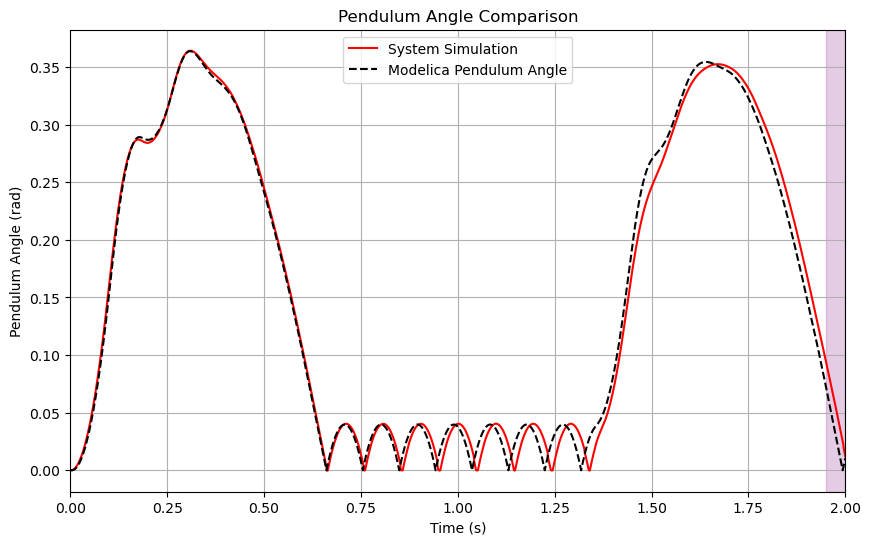

In [26]:
plt.figure(figsize=(10, 6))
plt.plot(t_pendulum, theta_pendulum, label='System Simulation', color='red')
plt.plot(ref_solutions['time'], ref_solutions['pendulum.theta'],
         label='Modelica Pendulum Angle', linestyle='--', color='black')
plt.axvspan(1.95, 2.2, color="purple", alpha=0.2)
plt.axvspan(3.8, 4.05, color="orange", alpha=0.2)
plt.xlim(0, t_pendulum[-1])
plt.xlabel('Time (s)')
plt.ylabel('Pendulum Angle (rad)')
plt.title('Pendulum Angle Comparison')
plt.legend()
plt.grid()
plt.show()

In [30]:
pid_hist = restored_history['PID']
i_out = pid_hist['I_out']['values']
t_pid = pid_hist['I_out']['time']

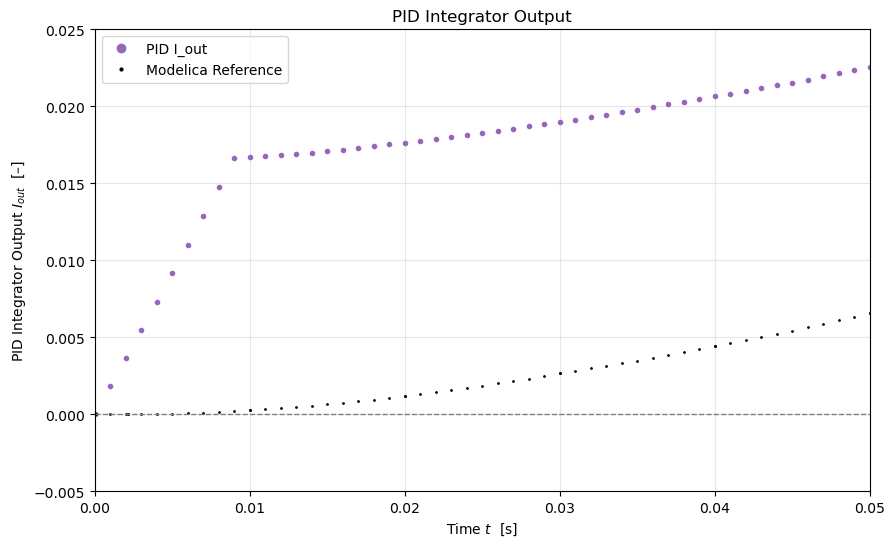

In [35]:
plt.figure(figsize=(10, 6))
plt.plot(t_pid, i_out, 'o', label="PID I_out", color="#9467bd", markersize=3)
plt.plot(ref_solutions['time'], ref_solutions['pid.I_out'], 'k.', label="Modelica Reference", markersize=2)
plt.axhline(0.0, color="#7f7f7f", linestyle="--", linewidth=1)
plt.xlim(0, 0.05)
plt.ylim(-0.005, 0.025)
plt.xlabel(r"Time $t$  [s]")
plt.ylabel(r"PID Integrator Output $I_{out}$  [–]")
plt.title("PID Integrator Output")
plt.legend(markerscale=2)
plt.grid(True, alpha=0.3)
plt.show()